# Ethiopia Climate Data - Exploratory Data Analysis (EDA)

This notebook performs data profiling, cleaning, and exploratory data analysis on Ethiopia’s climate dataset.  
The goal is to extract meaningful insights about temperature, precipitation, and climate variability trends relevant to COP32 analysis.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Loading and Preprocessing

The dataset is loaded using pandas. A Country column is added, and the YEAR and DOY columns are combined into a proper datetime format. A Month column is also extracted for seasonal analysis.

In [2]:
df = pd.read_csv("../data/ethiopia.csv")

df["Country"] = "Ethiopia"

# Convert YEAR + DOY → datetime
df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

# Extract month
df["Month"] = df["DATE"].dt.month

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,DATE,Month
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1


## 2. Data Cleaning

- NASA missing value indicator (-999) is replaced with NaN.
- Duplicate rows are identified and removed.
- Forward fill is applied to maintain continuity in time-series weather data.
- Rows with more than 30% missing values are removed.

In [3]:
# Replace NASA missing values
df.replace(-999, np.nan, inplace=True)

# Check duplicates
print("Duplicate rows:", df.duplicated().sum())

# Remove duplicates
df.drop_duplicates(inplace=True)

Duplicate rows: 0


## 3. Summary Statistics

Descriptive statistics are computed to understand the distribution, central tendency, and spread of all numerical variables.

In [4]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,Month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


## 4. Missing Value Analysis

This section identifies missing values per column and calculates the percentage of missing data.  
Columns with high missing rates (>5%) are highlighted for further consideration.

In [5]:
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Percent (%)": missing_percent
})

missing_table.sort_values("Percent (%)", ascending=False)

,Missing Values,Percent (%)
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


## 5. Outlier Detection

Z-score analysis is used to detect extreme values in key climate variables such as temperature, humidity, wind speed, and precipitation.  
Values with |Z| > 3 are flagged as outliers.

In [6]:
from scipy import stats

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = np.abs(stats.zscore(df[cols], nan_policy='omit'))

outliers = (z_scores > 3).sum(axis=0)

outliers

array([ 3,  0, 18, 95, 13,  3,  5])

## 6. Time Series Analysis

Monthly trends of temperature and precipitation are analyzed to understand seasonal climate patterns in Ethiopia.

In [9]:
df.replace(-999, np.nan, inplace=True)
df[cols] = df[cols].ffill()
df = df[df.isna().mean(axis=1) < 0.3]

In [10]:
df.to_csv("../data/ethiopia_clean.csv", index=False)


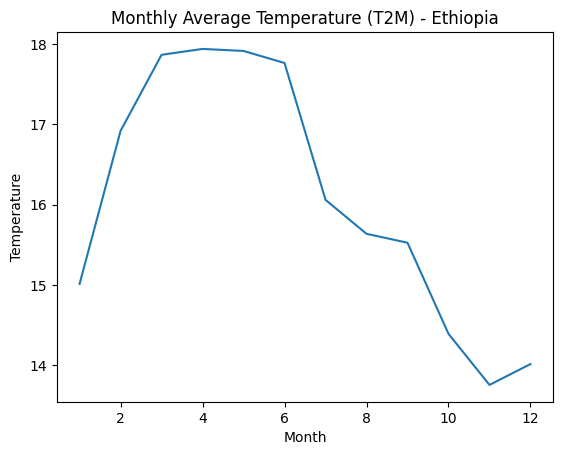

In [11]:
monthly_temp = df.groupby("Month")["T2M"].mean()

plt.figure()
plt.plot(monthly_temp.index, monthly_temp.values)
plt.title("Monthly Average Temperature (T2M) - Ethiopia")
plt.xlabel("Month")
plt.ylabel("Temperature")

plt.show()

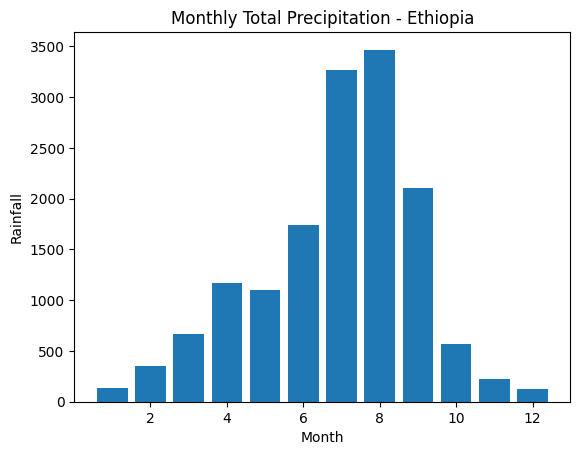

In [12]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

plt.figure()
plt.bar(monthly_rain.index, monthly_rain.values)
plt.title("Monthly Total Precipitation - Ethiopia")
plt.xlabel("Month")
plt.ylabel("Rainfall")

plt.show()

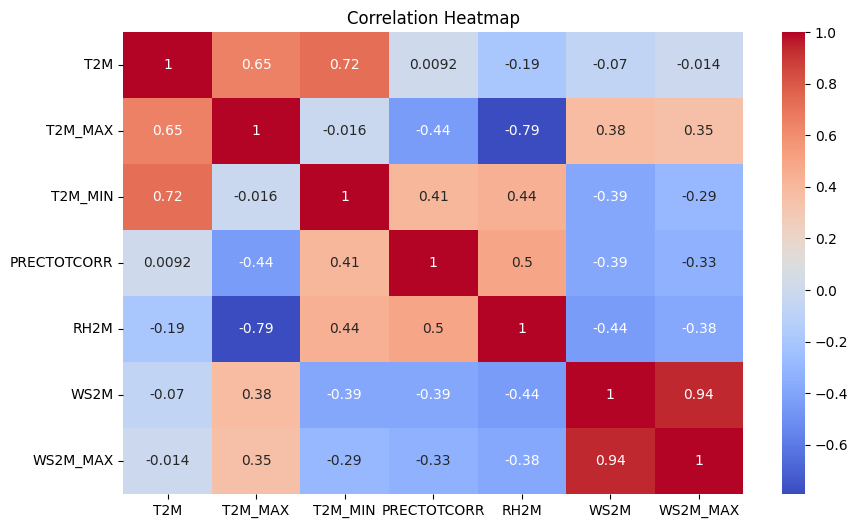

In [13]:
plt.figure(figsize=(10,6))
sns.heatmap(df[cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

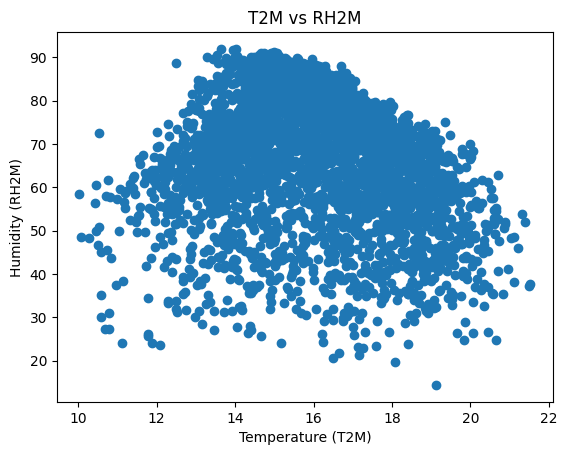

In [14]:
plt.figure()
plt.scatter(df["T2M"], df["RH2M"])
plt.xlabel("Temperature (T2M)")
plt.ylabel("Humidity (RH2M)")
plt.title("T2M vs RH2M")
plt.show()

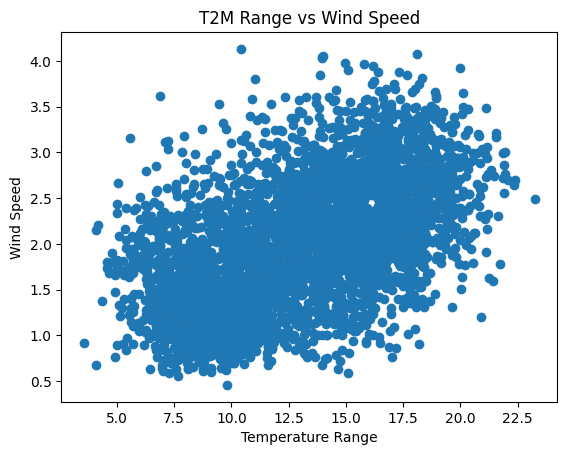

In [15]:
plt.figure()
plt.scatter(df["T2M_MAX"] - df["T2M_MIN"], df["WS2M"])
plt.xlabel("Temperature Range")
plt.ylabel("Wind Speed")
plt.title("T2M Range vs Wind Speed")
plt.show()

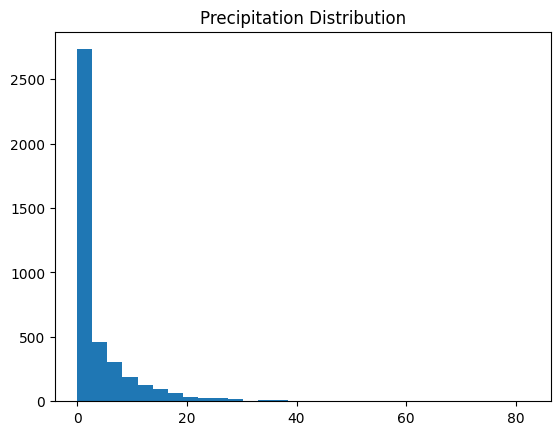

In [16]:
plt.figure()
plt.hist(df["PRECTOTCORR"].dropna(), bins=30)
plt.title("Precipitation Distribution")
plt.show()

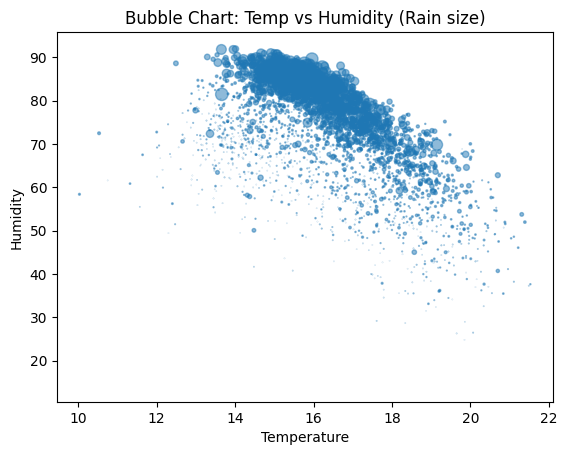

In [17]:
plt.figure()
plt.scatter(
    df["T2M"],
    df["RH2M"],
    s=df["PRECTOTCORR"] * 2,
    alpha=0.5
)

plt.xlabel("Temperature")
plt.ylabel("Humidity")
plt.title("Bubble Chart: Temp vs Humidity (Rain size)")
plt.show()

## 9. Key Insights

- Temperature shows clear seasonal variation across months.
- Precipitation is highly seasonal with distinct wet and dry periods.
- Humidity and temperature show measurable correlation.
- Wind speed has weaker correlation with other climate variables.
- Ethiopia shows moderate climate variability across the study period.